In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [5]:
# Load tất cả datasets
train = pd.read_csv("train.csv")
features = pd.read_csv("features.csv")
stores = pd.read_csv("stores.csv")

# **1. Xử lý Null**

Ta kiểm tra các giá trị Null cho từng bảng của tập dữ liệu

In [17]:
nan1 = features.isna().sum()

print(nan1)
print('-------------------')

nan2 = stores.isna().sum()
print(nan2)
print('-------------------')

nan3 = train.isna().sum()
print(nan3)

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
-------------------
Store    0
Type     0
Size     0
dtype: int64
-------------------
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


Nhận thấy ở bảng features các cột từ Markdown1 tới Unemployment đều có giá trị Nan

Phương pháp 1:

Ta dùng phương pháp loại bỏ Null để xóa các hàng có chứa dữ liệu Null. Tuy nhiên đây không phải là một phương pháp được khuyến khích dùng vì nó sẽ khiến ta mất đi lượng lớn dữ liệu và có thể dẫn đến việc dự đoán dữ liệu thiếu chính xác về sau

In [19]:
features_drop = features.dropna()
features_drop.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
92,1,2011-11-11,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,False
93,1,2011-11-18,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,False
94,1,2011-11-25,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,True
95,1,2011-12-02,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,False
96,1,2011-12-09,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,False
97,1,2011-12-16,51.63,3.159,5011.32,67.00,347.37,225.79,4011.37,219.179453,7.866,False
98,1,2011-12-23,47.96,3.112,2725.36,40.48,634.70,24.90,2739.43,219.357722,7.866,False
99,1,2011-12-30,44.55,3.129,5762.10,46011.38,260.36,983.65,4735.78,219.535990,7.866,True
100,1,2012-01-06,49.01,3.157,6277.39,21813.16,143.10,1450.13,8483.00,219.714258,7.348,False
101,1,2012-01-13,48.53,3.261,5183.29,8025.87,42.24,453.08,3719.38,219.892526,7.348,False


Nhận xét: lúc này các dòng có chứa giá trị null sẽ bị xóa đi mất

Phương pháp 2:

Ta dùng phương pháp điền khuyết( ở đây là các giá trị trung bình). Ta sẽ tính giá trị trung bình của các cột dữ liệu rồi sau đó sẽ điền các giá trị này vào các dữ liệu có giá trị Null. Bằng cách này ta có thể đảm bảo việc không bị mất mát dữ liệu

In [6]:
features_mean = features.fillna(features.mean(numeric_only=True))
features_mean.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.622857,7.808,False


Nhận xét: Các giá trị Null được thay thế bằng các giá trị trung bình ứng với các cột

Phương pháp 3:

Phương pháp nội suy là phương pháp điền các giá trị bị thiếu bằng cách sử dụng các giá trị xung quanh nó. Ở đây ta sử dụng hàm nội suy tuyến tính

In [27]:
features_inter = features.interpolate(method='linear')
features_inter.head(10)

<ipython-input-27-f3340c040cb3>:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  features_inter = features.interpolate(method='linear')


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


Nhận xét: Ở đây ta nhận thấy vẫn còn các giá trị Nan. Nguyên nhân là do đây là do đây là một dãy các giá trị Null nên hàm nội suy không thể dự đoán các giá trị này

In [28]:
nan_counts = features_inter.isna().sum()
print(nan_counts)

Store            0
Date             0
Temperature      0
Fuel_Price       0
MarkDown1       92
MarkDown2       92
MarkDown3       92
MarkDown4       92
MarkDown5       92
CPI              0
Unemployment     0
IsHoliday        0
dtype: int64


Vì vậy ta sẽ ta sẽ điền vào các dãy giá trị này bằng các giá trị dự đoán

In [29]:
features_inter = features_inter.ffill().bfill()
features_inter.head(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,10382.9,6115.67,215.07,2406.62,6551.42,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,10382.9,6115.67,215.07,2406.62,6551.42,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,10382.9,6115.67,215.07,2406.62,6551.42,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,10382.9,6115.67,215.07,2406.62,6551.42,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,10382.9,6115.67,215.07,2406.62,6551.42,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,10382.9,6115.67,215.07,2406.62,6551.42,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,10382.9,6115.67,215.07,2406.62,6551.42,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,10382.9,6115.67,215.07,2406.62,6551.42,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,10382.9,6115.67,215.07,2406.62,6551.42,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,10382.9,6115.67,215.07,2406.62,6551.42,210.622857,7.808,False


In [30]:
nan_counts = features_inter.isna().sum()
print(nan_counts)

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


Lúc này các giá trị Null đã được xử lý hoàn toàn. Tuy nhiên việc có quá nhiều dữ liệu Null liên tục như vậy sẽ khiến cho việc sử dụng hàm nội suy không hiệu quả

Ta gộp các bảng fetures, stores, train lại với nhau theo Store và Date

In [38]:
merged_df = pd.merge(train, features_drop, on=['Store', 'Date'], how='left')
df_drop = pd.merge(merged_df, stores, on='Store', how='left')
df_drop.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
1,1,1,2010-02-12,46039.49,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
2,1,1,2010-02-19,41595.55,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
3,1,1,2010-02-26,19403.54,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
4,1,1,2010-03-05,21827.90,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
5,1,1,2010-03-12,21043.39,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
6,1,1,2010-03-19,22136.64,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
7,1,1,2010-03-26,26229.21,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
8,1,1,2010-04-02,57258.43,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315
9,1,1,2010-04-09,42960.91,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,151315


Nhận xét sau khi merge các bảng lại với nhau ta nhận thấy việc xử lý các giá trị Null trước đó bằng phương pháp đầu tiên đã khiến ta mất một lượng lớn dữ liệu

In [41]:
df_drop = df_drop.dropna()
df_drop.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
92,1,1,2011-11-11,18689.54,False,59.11,3.297,10382.90,6115.67,215.07,2406.62,6551.42,217.998085,7.866,False,A,151315
93,1,1,2011-11-18,19050.66,False,62.25,3.308,6074.12,254.39,51.98,427.39,5988.57,218.220509,7.866,False,A,151315
94,1,1,2011-11-25,20911.25,True,60.14,3.236,410.31,98.00,55805.51,8.00,554.92,218.467621,7.866,True,A,151315
95,1,1,2011-12-02,25293.49,False,48.91,3.172,5629.51,68.00,1398.11,2084.64,20475.32,218.714733,7.866,False,A,151315
96,1,1,2011-12-09,33305.92,False,43.93,3.158,4640.65,19.00,105.02,3639.42,14461.82,218.961846,7.866,False,A,151315
97,1,1,2011-12-16,45773.03,False,51.63,3.159,5011.32,67.00,347.37,225.79,4011.37,219.179453,7.866,False,A,151315
98,1,1,2011-12-23,46788.75,False,47.96,3.112,2725.36,40.48,634.70,24.90,2739.43,219.357722,7.866,False,A,151315
99,1,1,2011-12-30,23350.88,True,44.55,3.129,5762.10,46011.38,260.36,983.65,4735.78,219.535990,7.866,True,A,151315
100,1,1,2012-01-06,16567.69,False,49.01,3.157,6277.39,21813.16,143.10,1450.13,8483.00,219.714258,7.348,False,A,151315
101,1,1,2012-01-13,16894.40,False,48.53,3.261,5183.29,8025.87,42.24,453.08,3719.38,219.892526,7.348,False,A,151315


In [7]:
merged_df = pd.merge(train, features_mean, on=['Store', 'Date'], how='left')
df_mean = pd.merge(merged_df, stores, on='Store', how='left')
df_mean.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,False,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.380643,8.106,False,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.215635,8.106,False,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.018042,8.106,False,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.820450,7.808,False,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.622857,7.808,False,A,151315


In [40]:
merged_df = pd.merge(train, features_inter, on=['Store', 'Date'], how='left')
df_inter = pd.merge(merged_df, stores, on='Store', how='left')
df_inter.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,10382.9,6115.67,215.07,2406.62,6551.42,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,10382.9,6115.67,215.07,2406.62,6551.42,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,10382.9,6115.67,215.07,2406.62,6551.42,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,10382.9,6115.67,215.07,2406.62,6551.42,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,10382.9,6115.67,215.07,2406.62,6551.42,211.350143,8.106,False,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,10382.9,6115.67,215.07,2406.62,6551.42,211.380643,8.106,False,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,10382.9,6115.67,215.07,2406.62,6551.42,211.215635,8.106,False,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,10382.9,6115.67,215.07,2406.62,6551.42,211.018042,8.106,False,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,10382.9,6115.67,215.07,2406.62,6551.42,210.820450,7.808,False,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,10382.9,6115.67,215.07,2406.62,6551.42,210.622857,7.808,False,A,151315


Ta sẽ tính RMSE theo Weekly_Sales để so sánh độ hiệu quả của từng phương thức

In [46]:
def train_model(df, label_col='Weekly_Sales'):
    df = df.select_dtypes(include=[np.number]).dropna()
    X = df.drop(columns=[label_col])
    y = df[label_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    train_rmse = mean_squared_error(y_train, model.predict(X_train)) ** 0.5
    test_rmse = mean_squared_error(y_test, model.predict(X_test)) ** 0.5

    return train_rmse, test_rmse

methods = ['Drop NaN', 'Fill Mean', 'Interpolate']
dfs = [df_drop, df_mean, df_inter]
train_rmses, test_rmses = [], []

for df_method in dfs:
    train_rmse, test_rmse = train_model(df_method)
    train_rmses.append(train_rmse)
    test_rmses.append(test_rmse)

Biểu đồ để trực quan hóa các sự khác nhau giữa 3 phương pháp

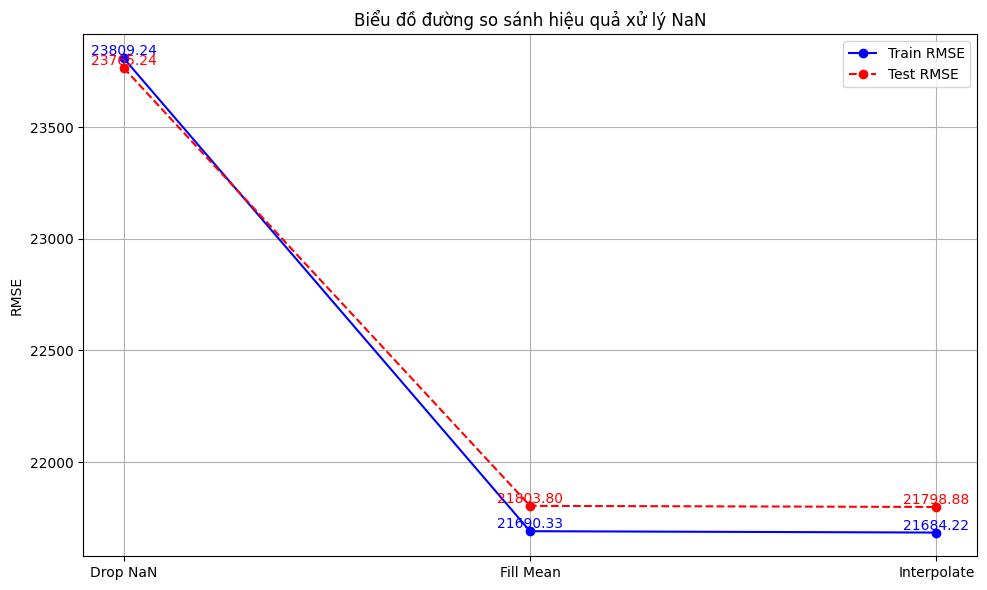

In [47]:
x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))

# Vẽ đường RMSE cho train và test
plt.plot(x, train_rmses, marker='o', linestyle='-', color='blue', label='Train RMSE')
plt.plot(x, test_rmses, marker='o', linestyle='--', color='red', label='Test RMSE')

# Gắn nhãn số RMSE trên từng điểm
for i in range(len(methods)):
    plt.text(x[i], train_rmses[i] + 0.1, f"{train_rmses[i]:.2f}", ha='center', va='bottom', color='blue')
    plt.text(x[i], test_rmses[i] + 0.1, f"{test_rmses[i]:.2f}", ha='center', va='bottom', color='red')

plt.xticks(x, methods)
plt.ylabel('RMSE')
plt.title('Biểu đồ đường so sánh hiệu quả xử lý NaN')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nhận xét: Ta thấy có thể thấy rằng phương pháp loại bỏ các giá trị Nan làm giá trị RMSE cao hơn đáng kể so với 2 phương pháp còn lại, do đó đây thường là phương pháp nên tránh dùng nếu có thể

# **2. Xử lý Outlier**

Ở đây ta sẽ chọn phương pháp điền khuyết bằng giá trị trung bình cho các giá trị Null

In [8]:
merged_df = pd.merge(train, features_mean, on=['Store', 'Date'], how='left')
df = pd.merge(merged_df, stores, on='Store', how='left')
df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,False,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.380643,8.106,False,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.215635,8.106,False,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.018042,8.106,False,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.820450,7.808,False,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.622857,7.808,False,A,151315


Để xác định được Outliers ta sẽ chọn ra các cột có giá trị số

In [105]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size'],
      dtype='object')


Phương pháp tính độ trải giữa(interquartile range): bằng cách tính giá trị ở giữa của nửa đầu và nửa sau của các giá trị để từ đó giúp ta xác định được các khoảng của các giá trị dữ liệu. Nếu nằm ngoài khoảng đó sẽ là Outlier

In [108]:
outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

Ở đây ta sẽ lấy 25% đầu tiên dữ liệu và 75% đầu tiên của dữ liệu và hiệu của 2 số liệu trên sẽ là là độ rộng của phần dữ liệu chính giữa

In [109]:
outlier_counts = outlier_flags.sum().sort_values(ascending=False)
print(outlier_counts)

MarkDown5       151432
MarkDown1       150681
MarkDown4       134967
MarkDown2       111248
Weekly_Sales     35521
Unemployment     32114
MarkDown3         3269
Temperature         69
Store                0
Fuel_Price           0
Dept                 0
CPI                  0
Size                 0
dtype: int64


Phương pháp 2: Sử dụng giá trị Z_score để xác định các outlier

In [106]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# 1. Tính Z-Score cho tất cả cột numeric
zscore_df = df[numeric_cols].apply(zscore)
zscore_df.columns = [f'zscore_{col}' for col in numeric_cols]

# 2. Tính Modified Z-Score cho tất cả cột numeric
def modified_zscore(series, threshold=3.5):
    median = np.median(series)
    mad = np.median(np.abs(series - median))
    if mad == 0:
        mad = 1e-6
    return (0.6745 * (series - median)) / mad

mod_zscore_df = df[numeric_cols].apply(modified_zscore)
mod_zscore_df.columns = [f'modz_{col}' for col in numeric_cols]

df_zsocre = pd.concat([df, zscore_df, mod_zscore_df], axis=1)

outliers_report = {}

for col in numeric_cols:
    # Outliers theo Z-Score (|Z| > 3)
    z_outliers = df_zsocre[np.abs(df_zsocre[f'zscore_{col}']) > 3]

    # Outliers theo Modified Z-Score (|MZ| > 3.5)
    modz_outliers = df_zsocre[np.abs(df_zsocre[f'modz_{col}']) > 3.5]

    outliers_report[col] = {
        'zscore_outliers': len(z_outliers),
        'modz_outliers': len(modz_outliers),
        'common_outliers': len(pd.merge(z_outliers, modz_outliers, how='inner'))
    }

outliers_df = pd.DataFrame(outliers_report).T
print("Outliers Report:")
print(outliers_df)

Outliers Report:
              zscore_outliers  modz_outliers  common_outliers
Store                       0              0                0
Dept                        0              0                0
Weekly_Sales             8848          42485             8848
Temperature                69              0                0
Fuel_Price                  0              0                0
MarkDown1                7376         150681             7376
MarkDown2                4956         111248             4956
MarkDown3                2773         137091             2773
MarkDown4                5804         134967             5804
MarkDown5                4677         151432             4677
CPI                         0              0                0
Unemployment            13756          18908            13756
Size                        0              0                0


Ở đây có sự khác biệt rõ rệt giữa Z_score bình thường và Z_score được điều chỉnh (modified) đó chính là modified Z_score dùng MAD(Median Absolute Deviation) giúp cho giá trị z này không bị ảnh hưởng bởi các giá trị gây nhiễu giúp phát hiện các Outlier hiệu quả hơn

Ví dụ Dữ liệu lương: [30, 35, 40, 38, 1000] → Mean bị kéo lệch, Z-Score của 1000 có thể không phát hiện được là outlier.


Trực quan hóa cho từng cột

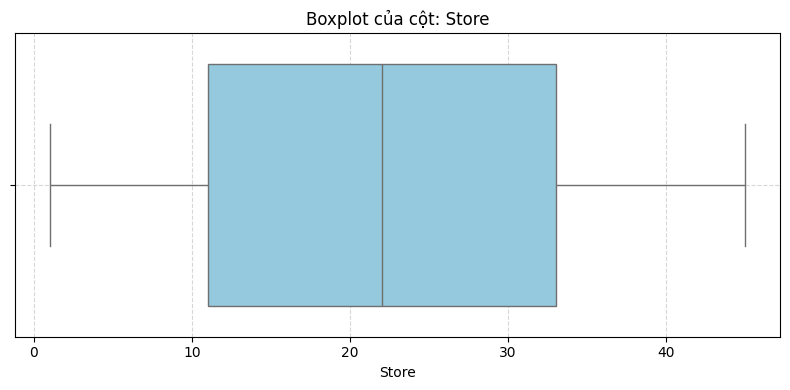

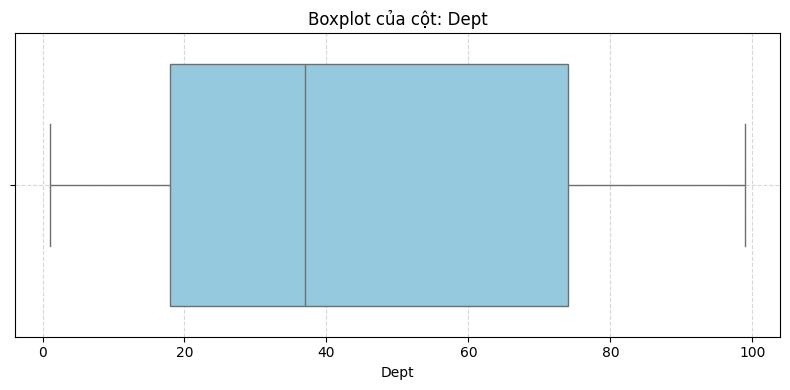

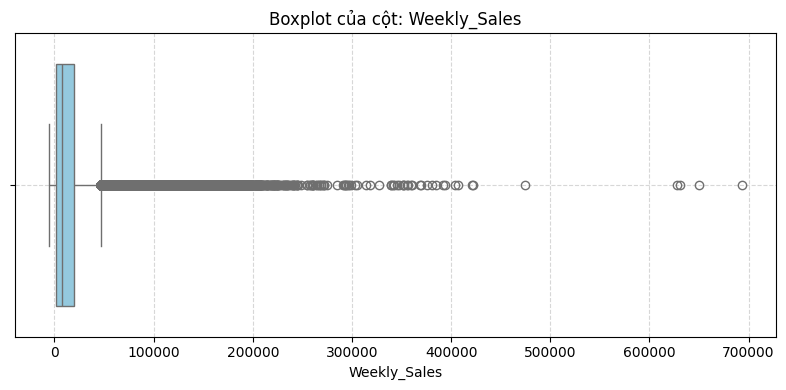

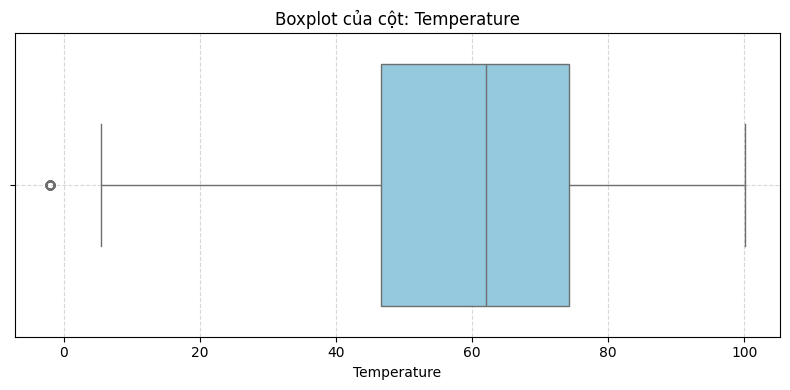

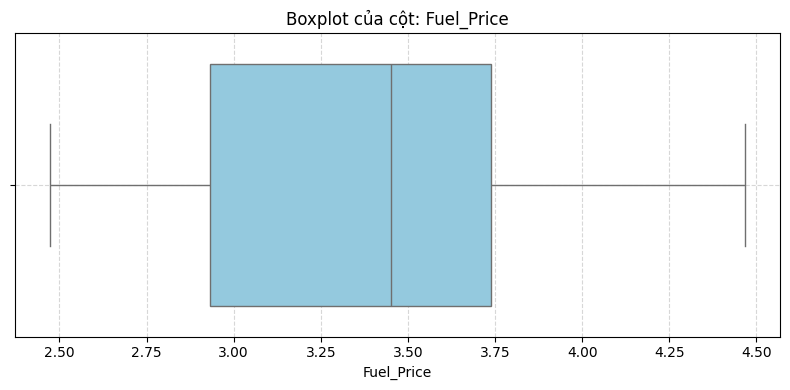

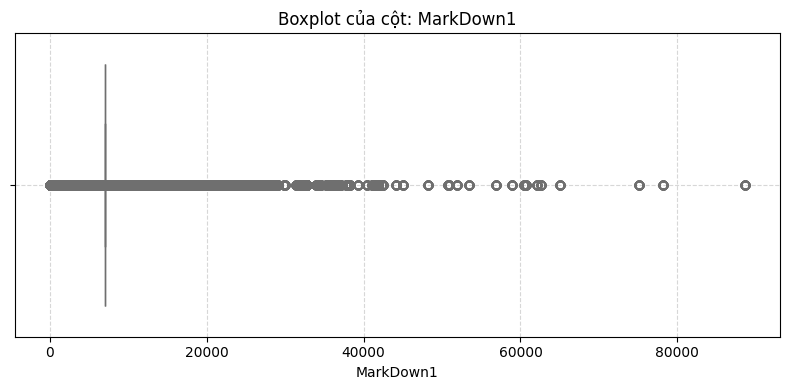

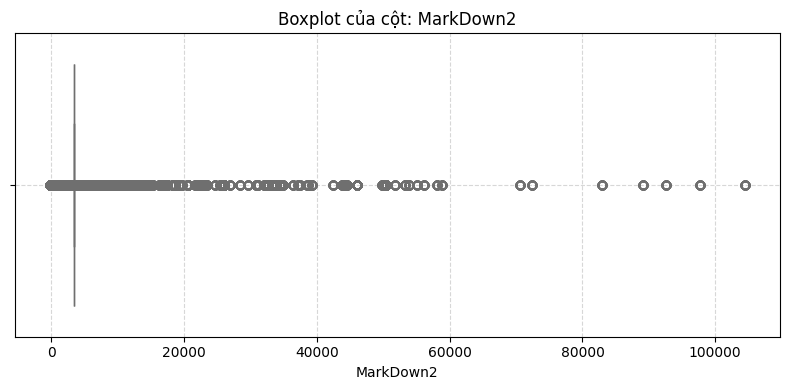

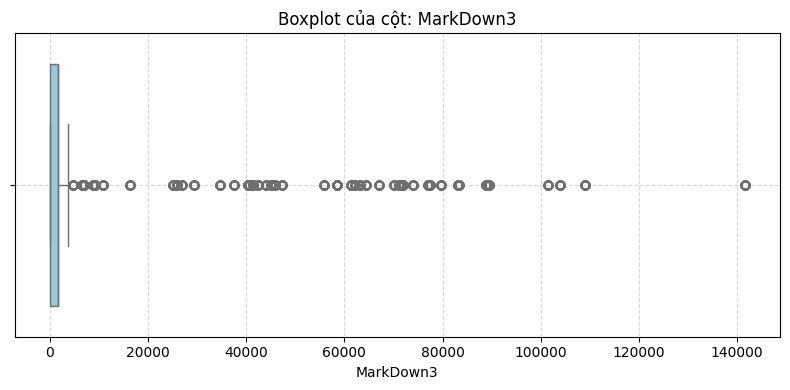

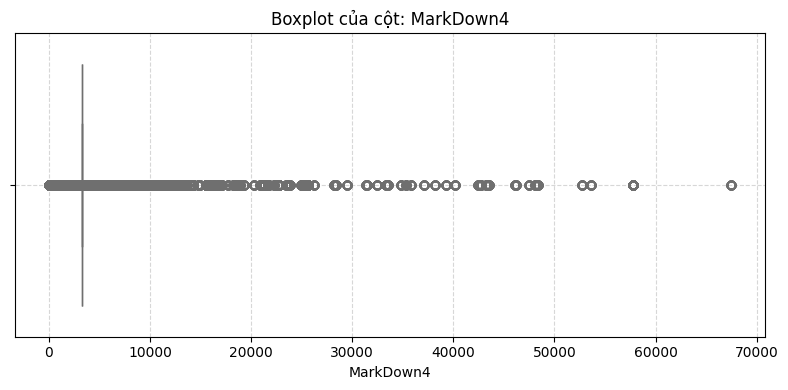

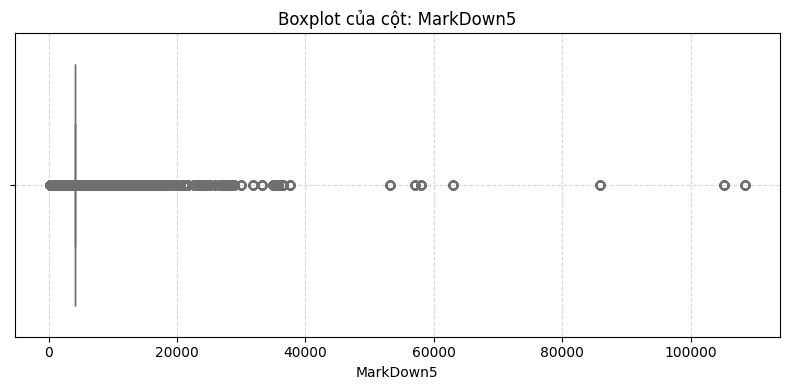

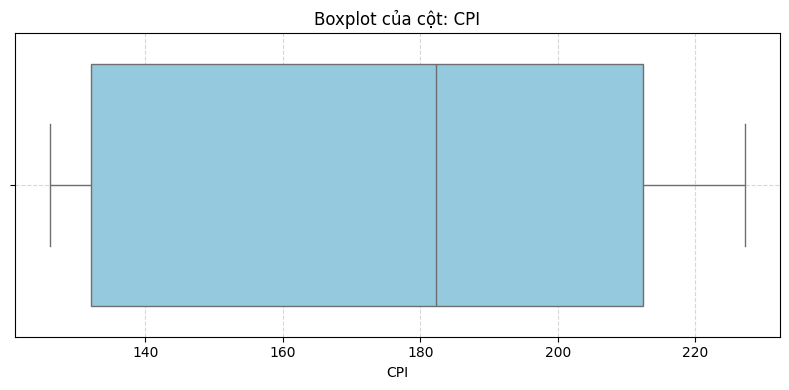

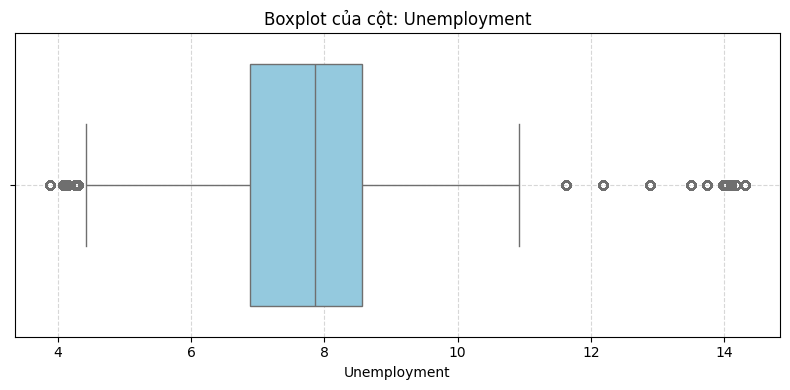

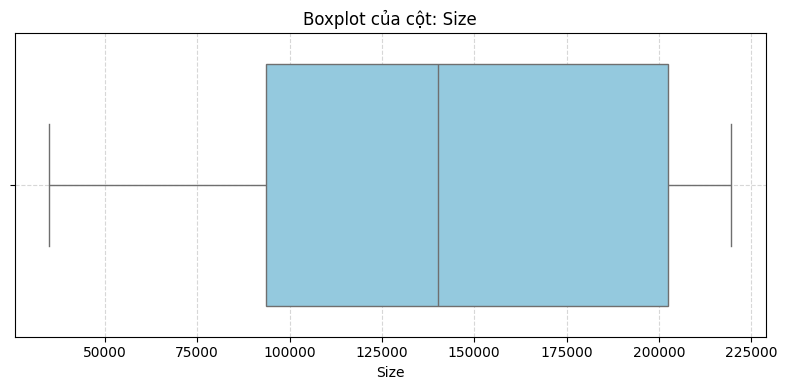

In [110]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot của cột: {col}')
    plt.xlabel(col)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# **3. Chuẩn hóa dữ liệu**

In [10]:
merged_df = pd.merge(train, features_mean, on=['Store', 'Date'], how='left')
df = pd.merge(merged_df, stores, on='Store', how='left')
df.drop(columns=['IsHoliday_y'], inplace=True)
df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)
numeric_cols = df.select_dtypes(include=[np.number]).columns

Phương pháp 1: Thay thế bằng giá trị median

In [185]:
df_copy = df.copy()
outlier_flags = pd.DataFrame(False, index=df_copy.index, columns=numeric_cols)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()
    df_copy[col] = np.where((df[col] < lower) | (df[col] > upper), median, df[col])
    outlier_flags[col] = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)

In [186]:
outlier_counts = outlier_flags.sum().sort_values(ascending=False)
print(outlier_counts)

Store           0
Dept            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Size            0
dtype: int64


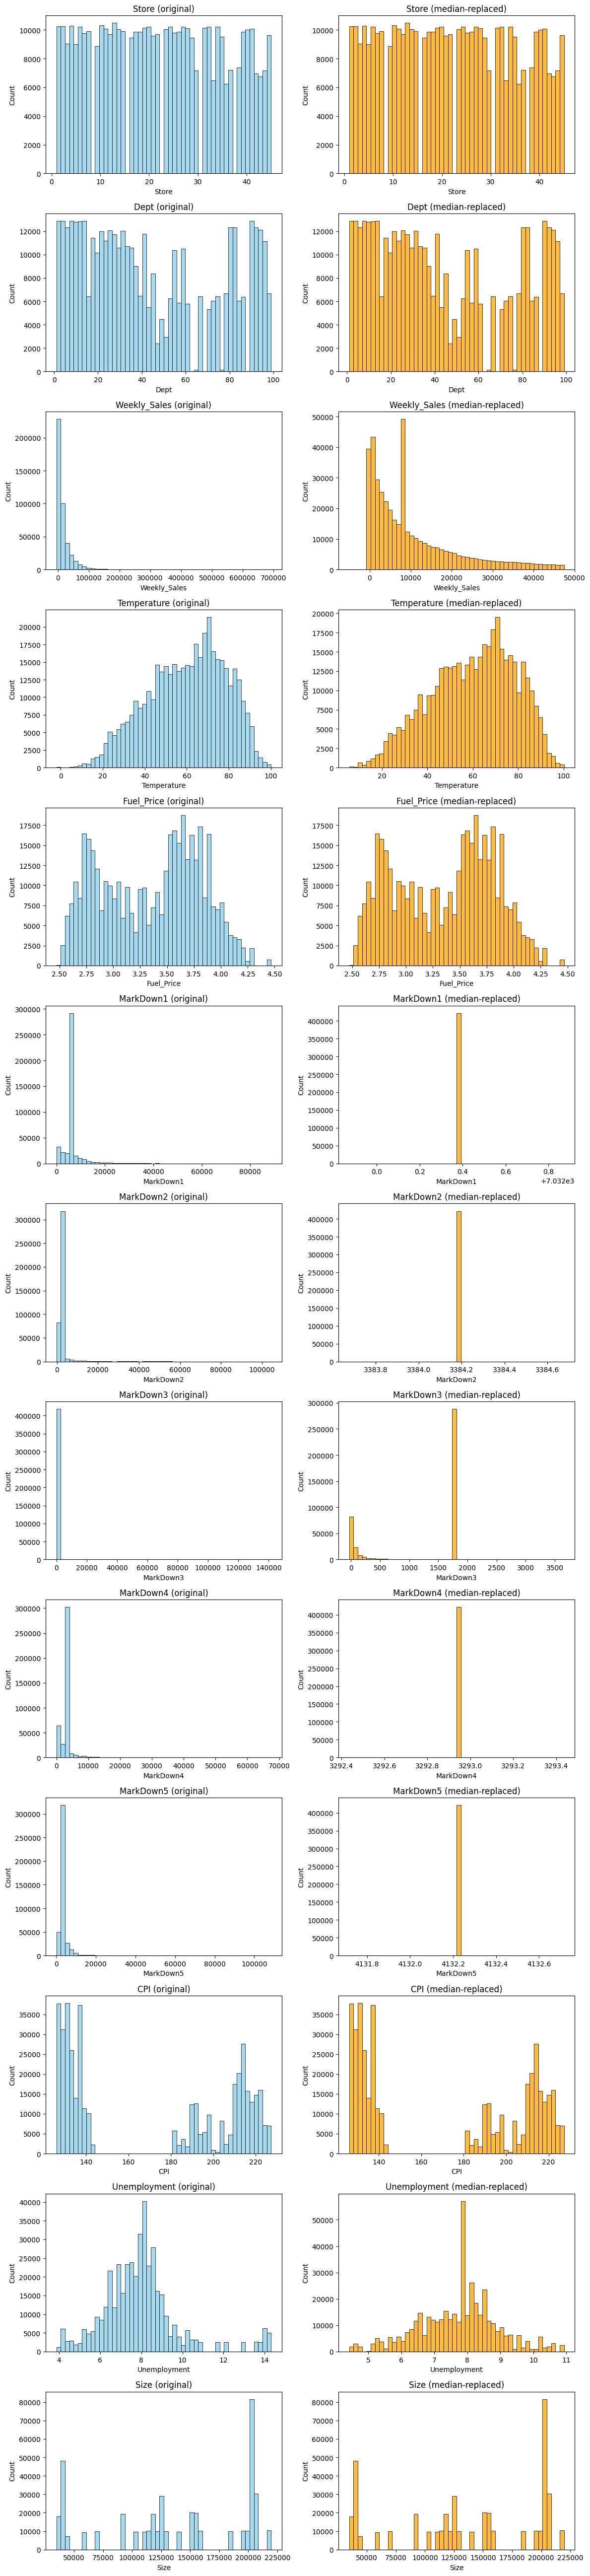

In [187]:
cols_to_plot = numeric_cols
plt.figure(figsize=(12, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    plt.subplot(len(cols_to_plot), 2, 2*i + 1)
    sns.histplot(df[col], bins=50, color='skyblue')
    plt.title(f'{col} (original)')
    plt.xlabel(col)

    plt.subplot(len(cols_to_plot), 2, 2*i + 2)
    sns.histplot(df_copy[col], bins=50, color='orange')
    plt.title(f'{col} (median-replaced)')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Nhận xét: như ta đã thấy các outlier bây giờ đã được thay bằng giá trị median

Phương pháp 2: Thay thế bằng cách biến đổi log để giảm ảnh hưởng

In [193]:
df_copy1 = df.copy()
df_copy1
for col in numeric_cols:
    if (df[col] > 0).all():
        df_copy1[f'{col}_log'] = np.log1p(df[col])
df_copy1.head()

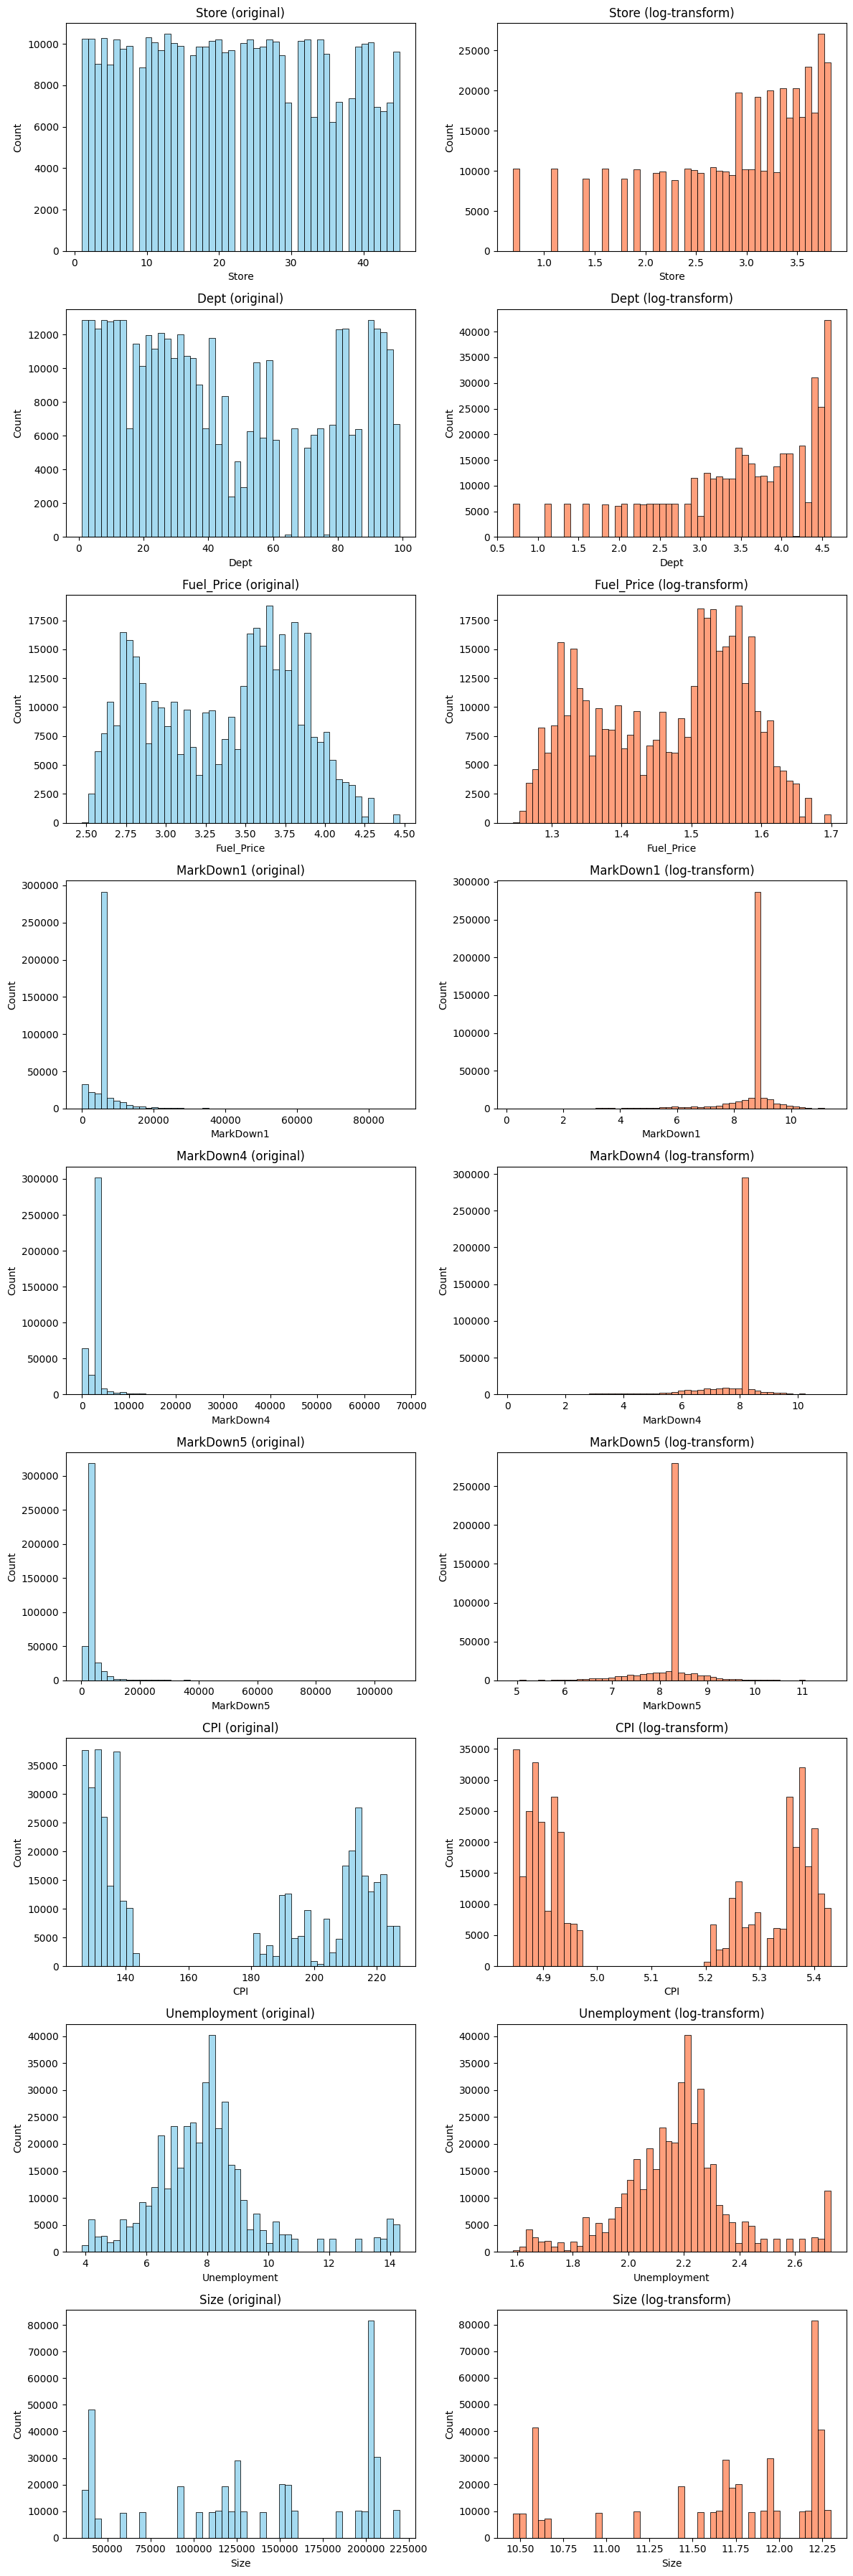

In [164]:
cols_to_plot = [col for col in numeric_cols if (df[col] > 0).all()]  # lọc các cột dương

plt.figure(figsize=(12, 4 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):

    plt.subplot(len(cols_to_plot), 2, 2*i + 1)
    sns.histplot(df[col], kde=False, bins=50, color='skyblue')
    plt.title(f'{col} (original)')
    plt.xlabel(col)


    plt.subplot(len(cols_to_plot), 2, 2*i + 2)
    sns.histplot(np.log1p(df[col]), kde=False, bins=50, color='coral')
    plt.title(f'{col} (log-transform)')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Phương pháp này làm giảm ảnh hưởng của các outlier bằng cách giảm giá trị của chúng. Thường cải thiện độ chính xác với mô hình tuyến tính hoặc phân phối lệch. Tuy nhiên phương pháp này chỉ sử dụng với các giá trị dương

Phương pháp chuẩn hóa Min-Max

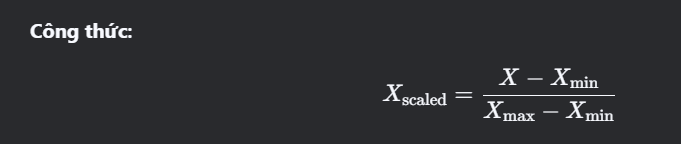

Đưa dữ liệu về khoảng [0, 1] hoặc [a, b] tùy chỉnh.

Ưu điểm:

    Dễ hiểu và dễ triển khai: Phù hợp cho người mới bắt đầu.

    Giữ nguyên phân phối: Dữ liệu vẫn giữ hình dạng phân phối ban đầu.

    Phù hợp cho dữ liệu không có outlier: Ví dụ: pixel ảnh (0-255), điểm thi (0-10).

Nhược điểm:

    Nhạy cảm với outlier: Một giá trị cực đoan (ví dụ: 1000 trong dãy số 1-100) sẽ kéo toàn bộ dữ liệu về gần 0.

    Không hiệu quả với dữ liệu lệch (skewed data): Ví dụ: dữ liệu doanh thu có phân phối lệch phải.

In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler(feature_range=(0, 1))
df_copy3 =df.copy()

df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df[numeric_cols]),
                         columns=[f'{col}_minmax' for col in numeric_cols],
                         index=df.index)

df_final = pd.concat([df_copy3, df_minmax], axis=1)
df_final = df_final.drop(columns=numeric_cols)
df_final.head()

,Date,IsHoliday,Type,Store_minmax,Dept_minmax,Weekly_Sales_minmax,Temperature_minmax,Fuel_Price_minmax,MarkDown1_minmax,MarkDown2_minmax,MarkDown3_minmax,MarkDown4_minmax,MarkDown5_minmax,CPI_minmax,Unemployment_minmax,Size_minmax
0,2010-02-05,False,A,0.0,0.0,0.042851,0.434149,0.050100,0.079327,0.034833,0.01263,0.048799,0.036879,0.840500,0.405118,0.630267
1,2010-02-12,True,A,0.0,0.0,0.073097,0.396967,0.038076,0.079327,0.034833,0.01263,0.048799,0.036879,0.841941,0.405118,0.630267
2,2010-02-19,False,A,0.0,0.0,0.066732,0.410861,0.021042,0.079327,0.034833,0.01263,0.048799,0.036879,0.842405,0.405118,0.630267
3,2010-02-26,False,A,0.0,0.0,0.034942,0.476419,0.044589,0.079327,0.034833,0.01263,0.048799,0.036879,0.842707,0.405118,0.630267
4,2010-03-05,False,A,0.0,0.0,0.038415,0.475147,0.076653,0.079327,0.034833,0.01263,0.048799,0.036879,0.843008,0.405118,0.630267


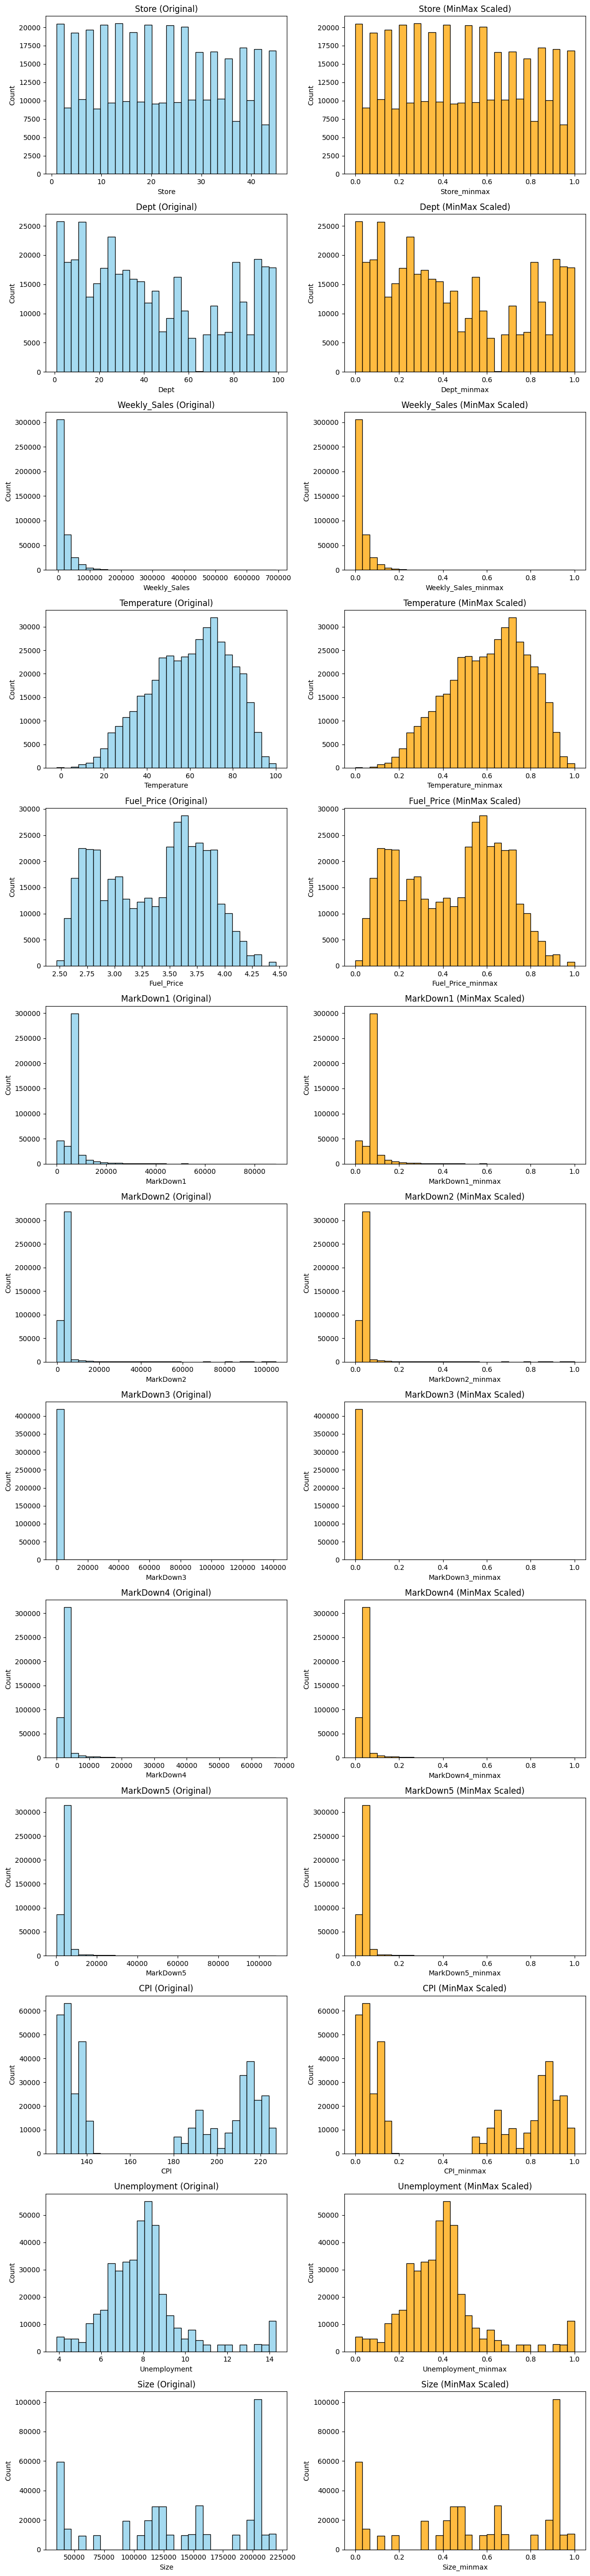

In [16]:
plt.figure(figsize=(12, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 2, 2*i + 1)
    sns.histplot(df[col], color='skyblue', bins=30)
    plt.title(f'{col} (Original)')
    plt.xlabel(col)

    plt.subplot(len(numeric_cols), 2, 2*i + 2)
    sns.histplot(df_final[f'{col}_minmax'], color='orange', bins=30)
    plt.title(f'{col} (MinMax Scaled)')
    plt.xlabel(f'{col}_minmax')

plt.tight_layout()
plt.show()

Phương pháp chuẩn hóa Robust

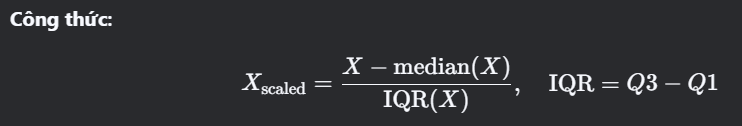

In [18]:
from sklearn.preprocessing import RobustScaler
scaler_robust = RobustScaler()
df_copy4 = df.copy()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df[numeric_cols]),
                         columns=[f'{col}_robust' for col in numeric_cols],
                         index=df.index)

df_final = pd.concat([df_copy4, df_robust], axis=1)
df_final = df_final.drop(columns=numeric_cols)
df_final.head()

,Date,IsHoliday,Type,Store_robust,Dept_robust,Weekly_Sales_robust,Temperature_robust,Fuel_Price_robust,MarkDown1_robust,MarkDown2_robust,MarkDown3_robust,MarkDown4_robust,MarkDown5_robust,CPI_robust,Unemployment_robust,Size_robust
0,2010-02-05,False,A,-0.954545,-0.642857,0.955107,-0.716667,-1.093168,0.0,0.0,0.0,0.0,0.0,0.357955,0.142772,0.1024
1,2010-02-12,True,A,-0.954545,-0.642857,2.119995,-0.854348,-1.122981,0.0,0.0,0.0,0.0,0.0,0.359769,0.142772,0.1024
2,2010-02-19,False,A,-0.954545,-0.642857,1.874828,-0.802899,-1.165217,0.0,0.0,0.0,0.0,0.0,0.360353,0.142772,0.1024
3,2010-02-26,False,A,-0.954545,-0.642857,0.650523,-0.560145,-1.106832,0.0,0.0,0.0,0.0,0.0,0.360733,0.142772,0.1024
4,2010-03-05,False,A,-0.954545,-0.642857,0.784272,-0.564855,-1.027329,0.0,0.0,0.0,0.0,0.0,0.361112,0.142772,0.1024


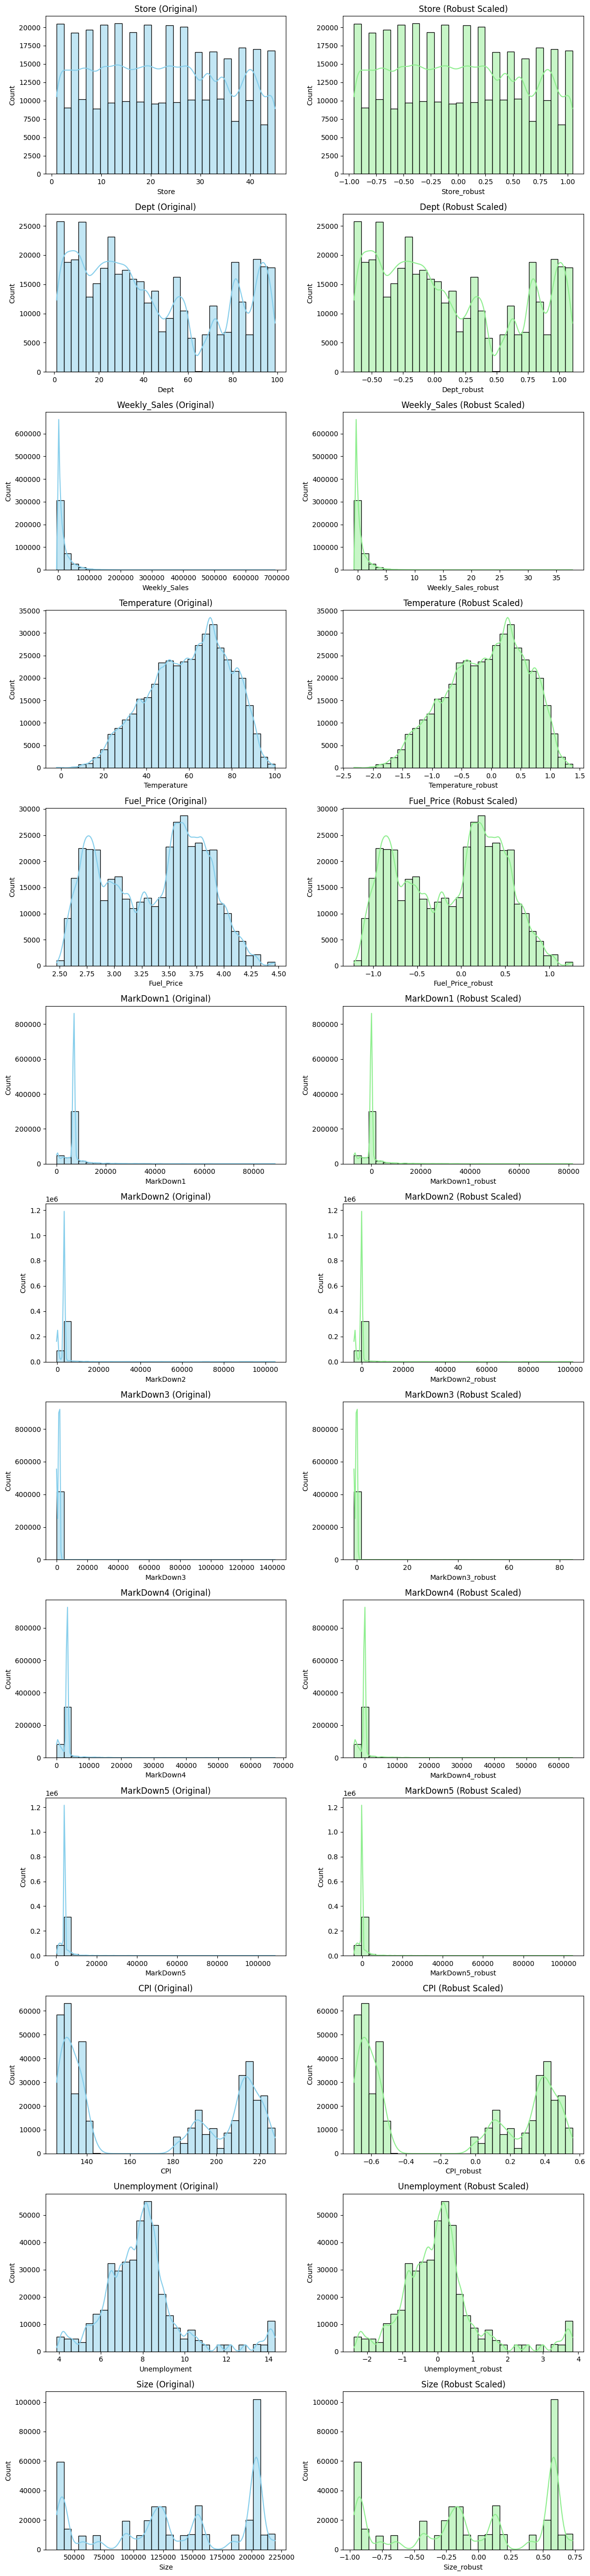

In [19]:
plt.figure(figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'{col} (Original)')
    plt.xlabel(col)

    plt.subplot(len(numeric_cols), 2, 2*i + 2)
    sns.histplot(df_final[f'{col}_robust'], kde=True, color='lightgreen', bins=30)
    plt.title(f'{col} (Robust Scaled)')
    plt.xlabel(f'{col}_robust')

plt.tight_layout()
plt.show()

Ưu điểm:

    Kháng outlier mạnh: Không bị ảnh hưởng bởi giá trị cực đoan.

    Phù hợp với dữ liệu lệch

    Giữ nguyên thông tin phân phối: Tập trung vào phần trung tâm của dữ liệu.

Nhược điểm:

    Không đưa dữ liệu về khoảng cố định: Giá trị scaled có thể âm hoặc dương tùy ý.

    Khó giải thích: Kết quả không nằm trong khoảng [0,1] như Min-Max.

# **4. Encoding**

In [154]:
merged_df = pd.merge(train, features_mean, on=['Store', 'Date'], how='left')
df = pd.merge(merged_df, stores, on='Store', how='left')
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    median = df[col].median()
    outlier_flags[col] = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,False,A,151315


Phương pháp 1: Label Encoding (Mã hóa nhãn)

Mã hóa nhãn là chiến thuật mã hóa chuyển dữ liệu dạng phân loại thành số nguyên, phù hợp với các đặc trưng phân loại chỉ nhận ít giá trị. Trong bộ dữ liệu này, ta có thể mã hóa cột `Type` từ A, B, C thành 0, 1, 2; hay cột `IsHoliday` từ True, False thành 1, 0.

In [155]:
from sklearn.preprocessing import LabelEncoder
df.drop(columns=['IsHoliday_y'], inplace=True)
df.rename(columns={'IsHoliday_x': 'IsHoliday'}, inplace=True)

le = LabelEncoder()
df['Type_enc'] = le.fit_transform(df['Type'])
df['IsHoliday'] = le.fit_transform(df['IsHoliday'])
df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Type_enc
0,1,1,2010-02-05,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,A,151315,0
1,1,1,2010-02-12,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,A,151315,0
2,1,1,2010-02-19,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,A,151315,0
3,1,1,2010-02-26,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,A,151315,0
4,1,1,2010-03-05,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,A,151315,0
5,1,1,2010-03-12,21043.39,0,57.79,2.667,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.380643,8.106,A,151315,0
6,1,1,2010-03-19,22136.64,0,54.58,2.720,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.215635,8.106,A,151315,0
7,1,1,2010-03-26,26229.21,0,51.45,2.732,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.018042,8.106,A,151315,0
8,1,1,2010-04-02,57258.43,0,62.27,2.719,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.820450,7.808,A,151315,0
9,1,1,2010-04-09,42960.91,0,65.86,2.770,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,210.622857,7.808,A,151315,0


**Ưu điểm:** Đơn giản, nhanh chóng.

**Nhược điểm** Giả định mối quan hệ thứ tự giữa các nhãn, có thể gây nhầm lẫn cho các mô hình Linear Regression. Không phù hợp với dữ liệu phi thứ tự.

Phương pháp 2: One-Hot Encoding

One-hot Encoding là chiến thuật mã hóa dữ liệu dạng phân loại bằng cách tách mỗi giá trị của biến thành một cột riêng biệt và gán giá trị cho cột đó là 0 (tương đương dòng dữ liệu không nhận giá trị của cột mới trong biến ban đầu) hoặc 1 (tương đương với dòng dữ liệu nhận giá trị của cột mới trong biến ban đầu).

In [156]:
df = pd.get_dummies(df, columns=['Type'], prefix='Type')
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size,Type_enc,Type_A,Type_B,Type_C
0,1,1,2010-02-05,24924.50,0,42.31,2.572,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.096358,8.106,151315,0,True,False,False
1,1,1,2010-02-12,46039.49,1,38.51,2.548,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.242170,8.106,151315,0,True,False,False
2,1,1,2010-02-19,41595.55,0,39.93,2.514,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.289143,8.106,151315,0,True,False,False
3,1,1,2010-02-26,19403.54,0,46.63,2.561,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.319643,8.106,151315,0,True,False,False
4,1,1,2010-03-05,21827.90,0,46.50,2.625,7032.371786,3384.176594,1760.10018,3292.935886,4132.216422,211.350143,8.106,151315,0,True,False,False


**Ưu điểm:** Không giả định thứ tự giữa các giá trị.

**Nhược điểm:** Tăng số chiều của bộ dữ liệu, khiến dữ liệu trở nên phức tạp hơn.

Phương pháp Binary Encoding

Ngoài hai chiến thuật mã hóa trên, ta còn có chiến thuật mã hóa nhị phân (Binary Encoding). Dành cho các biến phân loại có số lượng lớn giá trị khác nhau. Cách hoạt động: Mã hóa từng nhãn thành số nhị phân, sau đó chuyển từng bit thành cột.

Trong bộ dữ liệu này, ta có biến `Store` phù hợp với kiểu mã hóa này, tuy nhiên vì biến này đã nhận giá trị numerical và không tương quan nhiều với biến mục tiêu nên ta không cần thiết phải mã hóa.